## PseudotimeDE Overview

In many single-cell analyses we might be interested in how gene expression changes across continuously varying cell states, like developmental trajectories or the cell cycle. It has become common practice to first infer _pseudotime_ coordinates associated with each cell, which can serve as a proxy for the development or cell cycle stage, for example. Second, gene expression can be tested for associations with these inferred pseudotimes. However, the pseudotime estimates are themselves subject to measurement uncertainty, and traditional hypothesis testing methods don't account for this. The PseudotimeDE algorithm provides a principled approach for accounting for this uncertainty when identifying genes with differential expression across a pseudotime trajectory. This notebook walks through an application of the method to mouse dendritic cells after lipopolysaccharide stimulation (GEO GSE45719). The data have a strong, genuine pseudotime effect, and we will find many genes significant even after accounting for estimation uncertainty.

This example dataset and the overall algorithm are borrowed from the PseudotimeDE R [package]((https://github.com/SONGDONGYUAN1994/PseudotimeDE/)) and [vignette]((https://github.com/SONGDONGYUAN1994/PseudotimeDE/blob/master/vignettes/quickstart.Rmd)), the main difference is that the underlying simulation engine has been replaced with scDesigner. This speeds up the estimation and allows us to work with all 100 genes present in the filtered data rather than just the two (CCL5 and CXCL10) that are studied in the original vignette. 

### Setup

We load all the packages that we'll use throughout this vignette and set some important hyperparameters. The number of subsamples used (set when we subset them below) is also the number of permutations, and it controls the smallest possible p-value. The original PseudotimeDE paper recommends 1,000 but found relatively little empirical difference when using 100, which is what we will use in this notebook. The degrees of freedom (`DF`) controls the smoothness of the underlying spline models. Larger values allow for more flexibility but risk overfitting. To choose this hyperparameter, it's best to visualize the fitted trajectories to see whether they roughly fit the data under the null and alternative models. We will demonstrate this below.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scdesigner import datasets

from pseudotimede_py import (
    fit_likelihood_improvement,
    run_null_fits,
    subsample_pseudotimes,
    summarize_calibration,
)

DEMO_GENES = ["CCL5", "CXCL10"]
DF = 5
SEED = 0

To use PseudotimeDE, it's necessary to first infer the pseudotimes on many subsamples of the data. This is what gives the algorithm a chance to evaluate the uncertainty induced by pseudotime estimation. Below, we have precomputed the trajectories from 1,000 runs of the slingshot R package, each using 80% of the available cells. The inferred pseudotimes are stored them in a pandas DataFrame given by the`.obsm["pseudotime_subsamples"]` slot of the overall anndata experiment object. Each row corresponds to one cell and each column to a different subsample. If a cell was not contained within one of the subsamples, we expect an NA. The `subsample_pseudotimes` function reorganizes this matrix into a list of Series (one per subsample). Later, we will compute one permutation for each of these subsampled pseudotimes during our testing. To keep the runtime manageable, we'll only consider 100 of these pseudotime inference results, rather than the full 1000.

In [2]:
adata = datasets.lps()
subsamples = subsample_pseudotimes(adata)[:100]
genes = list(adata.var_names)
print(adata)
print(f"{len(subsamples)} subsamples, {len(subsamples[0])} cells each")

AnnData object with n_obs × n_vars = 390 × 100
    obs: 'pseudotime'
    uns: 'provenance'
    obsm: 'pseudotime_subsamples'
    layers: 'counts', None (.X)
100 subsamples, 312 cells each


We first visualize the two demo genes before doing any testing. Qualitatively, there does seem to be some variation in the gene expression for these genes across the inferred pseudotime trajectories.

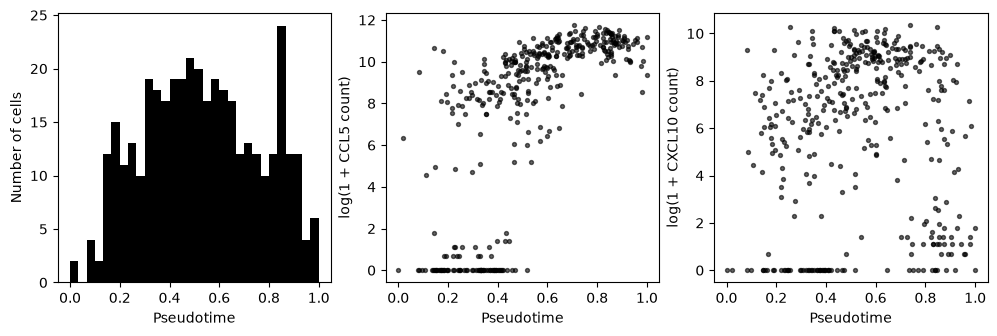

In [3]:
pseudotime = adata.obs["pseudotime"]
counts = pd.DataFrame(
    adata.layers["counts"].toarray(), index=adata.obs_names, columns=adata.var_names
)

fig, axes = plt.subplots(
    1, 1 + len(DEMO_GENES), figsize=(4 * (1 + len(DEMO_GENES)), 3.5)
)
axes[0].hist(pseudotime, bins=30, color="black")
axes[0].set_xlabel("Pseudotime")
axes[0].set_ylabel("Number of cells")
for ax, gene in zip(axes[1:], DEMO_GENES):
    ax.scatter(pseudotime, np.log1p(counts[gene]), s=8, color="black", alpha=0.6)
    ax.set_xlabel("Pseudotime")
    ax.set_ylabel(f"log(1 + {gene} count)")

### PseudotimeDE Method

The scatterplot below visualizes how pseudo-time estimates change across subsamples. The x-axis gives the originally estimated pseudo-time and the y-axis gives estimates across subsamples (color). Points that are far from the diagonal are cells whose estimated pseudotimes are unstable.

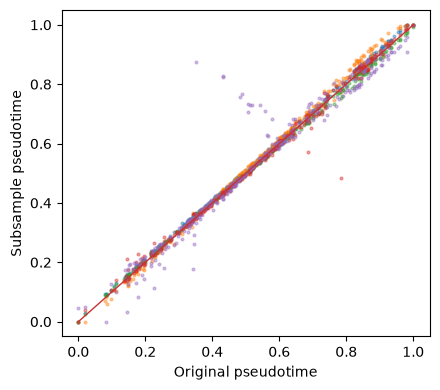

In [4]:
fig, ax = plt.subplots(figsize=(4.5, 4))
for sub in subsamples[:5]:
    ax.scatter(pseudotime.loc[sub.index], sub, s=4, alpha=0.4)
ax.plot([0, 1], [0, 1], color="#C73333", linewidth=1)
ax.set_xlabel("Original pseudotime")
ax.set_ylabel("Subsample pseudotime")
fig.tight_layout()
fig.show()

As a measure of how important pseudotime is on gene expression, we compute the genewise log-likelihood ratios between models fit with and without pseudotime as a predictor. This is returned in the `statistic` column as $2 (\ell_{\text{spline}} - \ell_{\text{intercept}})$. The factor of two is conventional for likelihood comparisons; we do not assume chi-square calibration for this adaptation. Large values indicate stronger evidence of expression variation along the supplied pseudotime.

In [5]:
observed, observed_models = fit_likelihood_improvement(
    adata, pseudotime, genes, df=DF, return_models=True
)
observed.head()

,n_cells,loglik_alternative,loglik_null,statistic,converged_alternative,converged_null
gene,,,,,,
CCL5,390,-3826.003651,-3878.325842,104.644382,True,True
CXCL10,390,-3187.487117,-3207.905645,40.837056,True,True
LYZ2,390,-4200.541331,-4256.832730,112.582798,True,True
CCL4,390,-3141.679631,-3168.652407,53.945552,True,True
IL12B,390,-3027.526564,-3056.750567,58.448008,True,True


Instead of trusting the asymptotic approximation, PseudotimeDE evaluates the significance of the test statistic $T$ using a permutation null. For each subsample we randomly permute the inferred pseudotimes. This breaks any relationship between the observed gene expression values and pseudotime. Recomputing the test statistic $T$ for each gene on these permuted samples gives its reference null distribution. This step can be time-consuming because it needs to fit both null and spline models for every subsample. The example below took 13 minutes for 100 genes and 100 subsamples.

In [6]:
start = time.perf_counter()
null = run_null_fits(
    adata, subsamples, genes, seed=SEED, df=DF,
    dispersion_formula=f"~ bs(pseudotime, df={DF})"
)
print(f"{len(subsamples)} subsamples, {len(genes)} genes: {time.perf_counter() - start:.0f} s")
null.head()

100 subsamples, 100 genes: 792 s


n_cells  loglik_alternative  loglik_null  statistic  \
replicate gene                                                          
1         CCL5        312        -3082.851083 -3082.871477   0.040788   
          CXCL10      312        -2548.301083 -2551.009816   5.417465   
          LYZ2        312        -3385.462095 -3386.114199   1.304208   
          CCL4        312        -2546.838137 -2550.523806   7.371339   
          IL12B       312        -2456.816363 -2459.312300   4.991874   

                  converged_alternative  converged_null  
replicate gene                                           
1         CCL5                     True            True  
          CXCL10                   True            True  
          LYZ2                     True            True  
          CCL4                     True            True  
          IL12B                    True            True

Values of $T$ that lie in the tail of the null distribution above are evidence of a true pseudotime effect, and they can be used to compute an empirical p-value $(1 + \#\{T_{\text{null}} \geq T_{\text{obs}}\}) / (B + 1)$. This formula shows why larger subsamples $B$ can provide more accurate p-values for strong effects. 

In [7]:
results = summarize_calibration(observed["statistic"], null)
results.loc[DEMO_GENES]

,statistic_observed,p_empirical
gene,,
CCL5,104.644382,0.009901
CXCL10,40.837056,0.009901


We visualize this permutation $p$-value for the demo genes in the plot below. The permutation null is the black background histogram and the observed test statistics are vertical red lines.

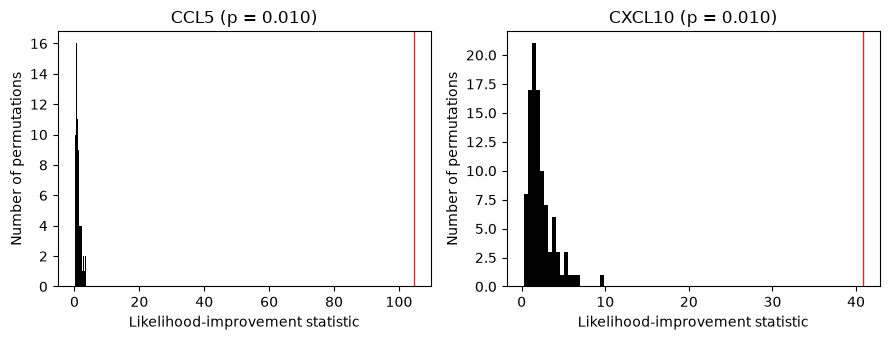

In [12]:
fig, axes = plt.subplots(
    1, len(DEMO_GENES), figsize=(4.5 * len(DEMO_GENES), 3.5), squeeze=False
)
for ax, gene in zip(axes[0], DEMO_GENES):
    gene_null = null.xs(gene, level="gene")
    ax.hist(gene_null["statistic"].dropna(), bins=20, color="black")
    ax.axvline(observed.loc[gene, "statistic"], color="#C73333", linewidth=1)
    ax.set_xlabel("Likelihood-improvement statistic")
    ax.set_ylabel("Number of permutations")
    ax.set_title(f"{gene} (p = {results.loc[gene, 'p_empirical']:.3f})")
fig.tight_layout()
fig.show()

fig.savefig("lps_pvalues.png", dpi=600, bbox_inches="tight")

### Diagnostics

We can overlay the fitted null and pseudotime-aware models on the real data. If these don't fit relatively well (given the constraints on the features they can refer to), then the pseudotime DE $p$-values may not be reliable. The curves below are the fitted means and the ribbons are the fitted standard deviations centered at those means. This plot requires the `scdiagnostics` package, which can be installed with `pip install scdiagnostics`.

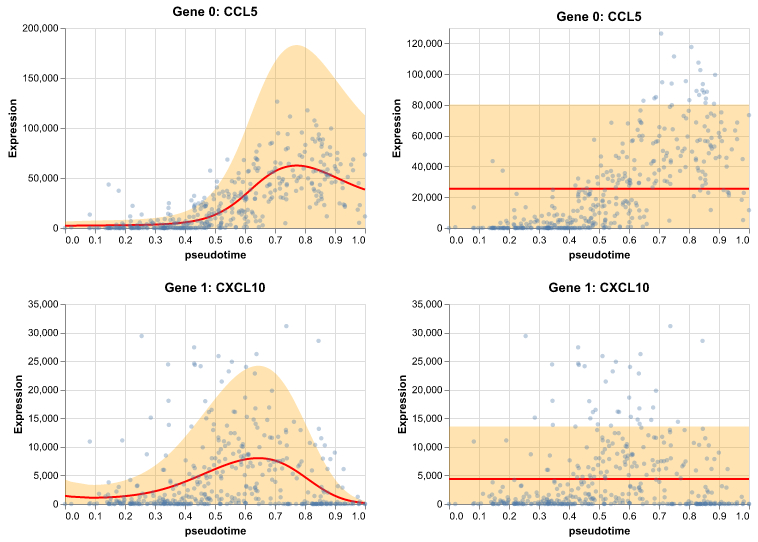

In [9]:
import altair as alt
from scdiagnostics import plot_fit_by_covariate
alt.data_transformers.enable("default")
alt.renderers.enable("png")

covariate_charts = []
for name in ("alternative", "null"):
    model = observed_models[name].select_genes(DEMO_GENES)
    chart = plot_fit_by_covariate(
       model,
       model.template,
       distribution="negbin",
       num_genes=len(DEMO_GENES),
   )
    covariate_charts.append(chart)

alt.hconcat(*covariate_charts)

Another check is to compare the model residuals against the fitted pseudotimes. A systematic trend in the residual might mean the model hasn't learned the true form of the relationship between that variable and the response. Alternatively, the assumed model may not be appropriate. The plot below shows the Pearson residuals based on the negative binomial variance $\mu + \frac{\mu^2}{r}$. There do seem to be some large values near the low pseudotimes, and these are visible in the plots above as well. Even with overdispersion modeled, the NB model has trouble fitting the outliers at low pseudotimes. It would be worth rerunning the analysis with these outlier cells removed to see whether the genes are still flagged as differentially expressed across pseudotimes.

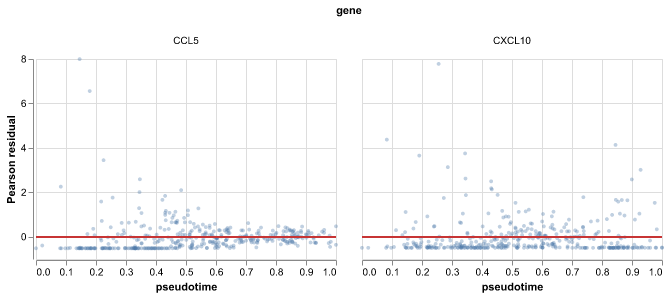

In [10]:
from pseudotimede_py.diagnostics import model_fit_tables

_, _, fit_residuals = model_fit_tables(observed_models, DEMO_GENES)

residual_data = fit_residuals.query("model == 'alternative'")
base = alt.Chart(residual_data).encode(
    x=alt.X("pseudotime:Q"), y=alt.Y("pearson:Q", title="Pearson residual")
)
points = base.mark_circle(size=15, opacity=0.35).encode(tooltip=["cell:N", "pearson:Q"])
zero = alt.Chart(residual_data).mark_rule(color="#C73333").encode(y=alt.datum(0))
(points + zero).properties(width=300, height=200).facet(column="gene:N")

Last, we check that the optimization for both the null and pseudotime fits has converged. Our statistic depends on the model likelihood, and if the model hasn't converged, then the likelihood might still change if we train it for longer. For the gene gene below, we can see that both the null and alternative fits have plateaued, so our test statistic is okay. If we had seen that the curves were still decreasing, then it would be worth either increasing the number of epochs or requiring a more stringent convergence criterion during the estimation stage.

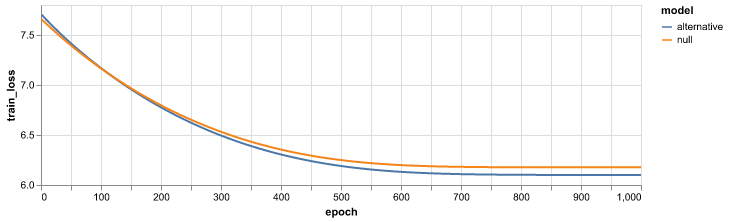

In [11]:
loss_history = pd.concat([
    pd.DataFrame(model.marginal.fit_history).assign(model=name)
    for name, model in observed_models.items()
], ignore_index=True)
alt.Chart(loss_history).mark_line().encode(
    x="epoch:Q", y=alt.Y("train_loss:Q", scale=alt.Scale(zero=False)),
    color="model:N",
).properties(width=600, height=180)